## Tech Challenge - fase 3

In [1]:
#importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#importando o nosso arquivo já tratado
df = pd.read_csv('state_of_data_limpo.csv', sep = ',')

/tmp/ipykernel_687/3087929664.py:2: DtypeWarning: Columns (120,121,122,123,152) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('state_of_data_limpo.csv', sep = ',')


In [4]:
#verificando a dimensão do arquivo
df.shape

(19862, 153)

In [5]:
#Analise das 5 primeiras colunas
df.head()

,id,Idade,Faixa_idade,Genero,Cor_raca_etnia,PCD,experiencia_profissional_prejudicada,aspectos_prejudicados,vive_no_brasil,Estado_onde_mora,...,IBM_DataStage_ETL,SAP_BW_ETL_ETL,SQL_Server_Integration_Services_SSIS_ETL,SAS_Data_Integration_ETL,Qlik_Sense_ETL,Knime_ETL,Databricks_ETL,Nao_utilizo_ferramentas_de_ETL_ETL,ano_pesquisa,data_hora_envio
0,reb94rv0msth7q4nreb94riaq80iz3yi,18,17-21,Masculino,Branca,Não,NaN,NaN,1,Rio Grande do Sul (RS),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024,16/10/2024 11:19:17
1,1zc66g69jjt49y32l1zc66g8wqj79m4e,18,17-21,Masculino,Branca,Não,NaN,NaN,1,Santa Catarina (SC),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024,16/10/2024 20:45:31
2,uu99wmam4n5kc2uu99wmydf0rk7l58f7,18,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,1,São Paulo (SP),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,17/10/2024 18:10:59
3,3ynsw7z0hl5hhpbfvaeqk73ynsw7z04l,18,17-21,Masculino,Branca,Não,NaN,NaN,1,São Paulo (SP),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024,22/10/2024 18:03:00
4,v6bji2ct5xckpl1uouv6bjiotkrf3b4f,18,17-21,Masculino,Branca,Não,NaN,NaN,1,São Paulo (SP),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,23/10/2024 01:33:23


In [7]:
#descrevendo os dados
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,19862,9928,tdm01ed14n10hdl0rkrtdm01edwge73j,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Idade,19862.0,NaN,NaN,NaN,31.335414,7.037341,18.0,27.0,30.0,35.0,70.0
Faixa_idade,19862,9,25-29,6498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genero,19862,4,Masculino,14962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cor_raca_etnia,19860,7,Branca,12864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Knime_ETL,8616.0,NaN,NaN,NaN,0.018106,0.133342,0.0,0.0,0.0,0.0,1.0
Databricks_ETL,8616.0,NaN,NaN,NaN,0.196611,0.397459,0.0,0.0,0.0,0.0,1.0
Nao_utilizo_ferramentas_de_ETL_ETL,8616.0,NaN,NaN,NaN,0.170613,0.376192,0.0,0.0,0.0,0.0,1.0
ano_pesquisa,19862.0,NaN,NaN,NaN,2023.863861,0.778852,2023.0,2023.0,2024.0,2024.0,2025.0


In [8]:
#verificando a quantidade de registros nulos
df.isnull().sum().sort_values(ascending=False)

,0
Cargo_como_Gestor,19862
Tipos_de_uso_de_AI_Generativa_e_LLMs_na_empresa,19862
Qual_o_numero_aproximado_de_pessoas_que_atuam_com_dados_na_sua_empresa_hoje,19862
AI_Generativa_e_uma_prioridade_em_sua_empresa,19862
Motivos_que_levam_a_empresa_a_nao_usar_AI_Genrativa_e_LLMs,19862
...,...
Atuacao,0
Caso_sua_empresa_decida_pelo_modelo_100_presencial_qual_sera_sua_atitude,0
Atualmente_qual_a_sua_forma_de_trabalho,0
Voce_esta_satisfeito_na_sua_empresa_atual,0


In [9]:
#Verificando os valores unicos
df.nunique().sort_values(ascending=False)

,0
id,9928
data_hora_envio,6079
Quais_dos_bancos_de_dados_fontes_de_dados_listados_abaixo_voce_utiliza_no_trabalho_BD,4027
Ferramenta_de_BI_utilizada_no_dia_a_dia_BI,1396
aspectos_prejudicados,994
...,...
Qual_o_numero_aproximado_de_pessoas_que_atuam_com_dados_na_sua_empresa_hoje,0
AI_Generativa_e_uma_prioridade_em_sua_empresa,0
Tipos_de_uso_de_AI_Generativa_e_LLMs_na_empresa,0
Quais_desses_papeis_cargos_fazem_parte_do_time_ou_chapter_de_dados_da_sua_empresa,0


In [10]:
df['id'].duplicated().sum() #verificando a quantidade de ids duplicados

np.int64(9934)

In [11]:
df[df['id'].duplicated(keep=False)].sort_values('id').tail(20) #verificando se as respostas são as mesmas

,id,Idade,Faixa_idade,Genero,Cor_raca_etnia,PCD,experiencia_profissional_prejudicada,aspectos_prejudicados,vive_no_brasil,Estado_onde_mora,...,IBM_DataStage_ETL,SAP_BW_ETL_ETL,SQL_Server_Integration_Services_SSIS_ETL,SAS_Data_Integration_ETL,Qlik_Sense_ETL,Knime_ETL,Databricks_ETL,Nao_utilizo_ferramentas_de_ETL_ETL,ano_pesquisa,data_hora_envio
15003,zy7hsey7pigk6d4a4zy7hsm7bh1vcozc,28,25-29,Masculino,Branca,Não,NaN,NaN,1,São Paulo (SP),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN
11223,zy7hsey7pigk6d4a4zy7hsm7bh1vcozc,28,25-29,Masculino,Branca,Não,NaN,NaN,1,São Paulo (SP),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN
7403,zyd47ysqap5wwozcsjzzyd40usp7j9ft,52,50-54,Masculino,Branca,Não,NaN,NaN,1,São Paulo (SP),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,21/11/2024 20:10:10
3680,zyd47ysqap5wwozcsjzzyd40usp7j9ft,52,50-54,Masculino,Branca,Não,NaN,NaN,1,São Paulo (SP),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,21/11/2024 20:10:10
16004,zyf0qeg1si6vyodqbizyf0f4wmnuskjz,31,30-34,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,1,Rio de Janeiro (RJ),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,13/11/2025 11:11:42
18432,zyf0qeg1si6vyodqbizyf0f4wmnuskjz,31,30-34,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,1,Rio de Janeiro (RJ),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,13/11/2025 11:11:42
19309,zykrtjh2ldqrkr7gzykrtj7tm3lo57de,26,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,1,Distrito Federal (DF),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,17/12/2025 13:18:13
16881,zykrtjh2ldqrkr7gzykrtj7tm3lo57de,26,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,1,Distrito Federal (DF),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,17/12/2025 13:18:13
11224,zyppgxzxko25qkgwsbrgpzyppgxzxs81,32,30-34,Masculino,Branca,Não,NaN,NaN,1,Rio Grande do Norte (RN),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN
15004,zyppgxzxko25qkgwsbrgpzyppgxzxs81,32,30-34,Masculino,Branca,Não,NaN,NaN,1,Rio Grande do Norte (RN),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN


In [12]:
df_limpo = df.drop_duplicates(subset='id', keep='first') #limpando os registros repetidos do id apos verificar que eles possuem o mesmo registro

In [13]:
print(df_limpo.columns.tolist()) #Transformamos as colunas em uma lista, para conseguir verificar todas as colunas do DataFrame


['id', 'Idade', 'Faixa_idade', 'Genero', 'Cor_raca_etnia', 'PCD', 'experiencia_profissional_prejudicada', 'aspectos_prejudicados', 'vive_no_brasil', 'Estado_onde_mora', 'uf_onde_mora', 'Regiao_onde_mora', 'Mudou_de_Estado', 'Regiao_de_origem', 'Nivel_de_Ensino', 'Area_de_Formacao', 'Qual_sua_situacao_atual_de_trabalho', 'Setor', 'Numero_de_Funcionarios', 'Gestor', 'Cargo_como_Gestor', 'Cargo_Atual', 'Nivel', 'Faixa_salarial', 'Quanto_tempo_de_experiencia_na_area_de_dados_voce_tem', 'Voce_esta_satisfeito_na_sua_empresa_atual', 'Qual_o_principal_motivo_da_sua_insatisfacao_com_a_empresa_atual', 'Atualmente_qual_a_sua_forma_de_trabalho', 'Qual_a_forma_de_trabalho_ideal_para_voce', 'Caso_sua_empresa_decida_pelo_modelo_100_presencial_qual_sera_sua_atitude', 'Qual_o_numero_aproximado_de_pessoas_que_atuam_com_dados_na_sua_empresa_hoje', 'Quais_desses_papeis_cargos_fazem_parte_do_time_ou_chapter_de_dados_da_sua_empresa', 'AI_Generativa_e_uma_prioridade_em_sua_empresa', 'Tipos_de_uso_de_AI_Gener

In [14]:
#Para responder as perguntas, optamos por seguir apenas com os dados que têm experiencia em dados, ja que a pesquisa é voltada para os profissionais em dados
#Criando um DF retirando os casos sem experiencia para responder a primeira pergunta
df_com_experiencia = df_limpo[
    df['Quanto_tempo_de_experiencia_na_area_de_dados_voce_tem']
    != 'Não tenho experiência na área de dados'
].copy()

/tmp/ipykernel_687/2049504444.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_com_experiencia = df_limpo[


In [15]:
df_com_experiencia.shape #verificando o tamanho no novo df

(9482, 153)

# Iniciando a geração dos gráficos

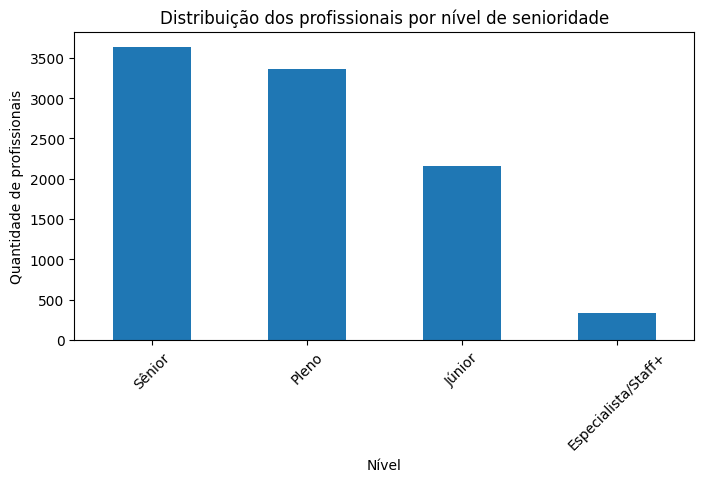

In [17]:
#Este grafico tem como objetivo verificar a distribuição da senioridade por quantidade de profissionais na area
df_com_experiencia['Nivel'].value_counts().plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Distribuição dos profissionais por nível de senioridade')
plt.xlabel('Nível')
plt.ylabel('Quantidade de profissionais')
plt.xticks(rotation=45)
plt.show()

In [18]:
df_com_experiencia['Faixa_salarial'].value_counts() #Verificamos que a faixa salarial não era um número, portanto não conseguiriamos trabalhar com ela para calculos

,count
Faixa_salarial,
de R$ 8.001/mês a R$ 12.000/mês,2386
de R$ 4.001/mês a R$ 6.000/mês,1502
de R$ 6.001/mês a R$ 8.000/mês,1453
de R$ 12.001/mês a R$ 16.000/mês,1333
de R$ 3.001/mês a R$ 4.000/mês,673
de R$ 16.001/mês a R$ 20.000/mês,578
de R$ 2.001/mês a R$ 3.000/mês,533
de R$ 1.001/mês a R$ 2.000/mês,387
de R$ 20.001/mês a R$ 25.000/mês,244


In [19]:
#Então fizemos um mapeamento para uma nova coluna colocando valores médios/aproximados dessa faixa, não é valor exato, é apenas para ter algum numero para trabalhar
mapa_salario = {
    'Menos de R$ 1.000/mês': 800,
    'de R$ 1.001/mês a R$ 2.000/mês': 1500,
    'de R$ 2.001/mês a R$ 3.000/mês': 2500,
    'de R$ 3.001/mês a R$ 4.000/mês': 3500,
    'de R$ 4.001/mês a R$ 6.000/mês': 5000,
    'de R$ 6.001/mês a R$ 8.000/mês': 7000,
    'de R$ 8.001/mês a R$ 12.000/mês': 10000,
    'de R$ 12.001/mês a R$ 16.000/mês': 14000,
    'de R$ 16.001/mês a R$ 20.000/mês': 18000,
    'de R$ 20.001/mês a R$ 25.000/mês': 22500,
    'de R$ 25.001/mês a R$ 30.000/mês': 27500,
    'de R$ 30.001/mês a R$ 40.000/mês': 35000
}
df_com_experiencia['Salario_medio_faixa'] = (
    df_com_experiencia['Faixa_salarial'].map(mapa_salario)
)

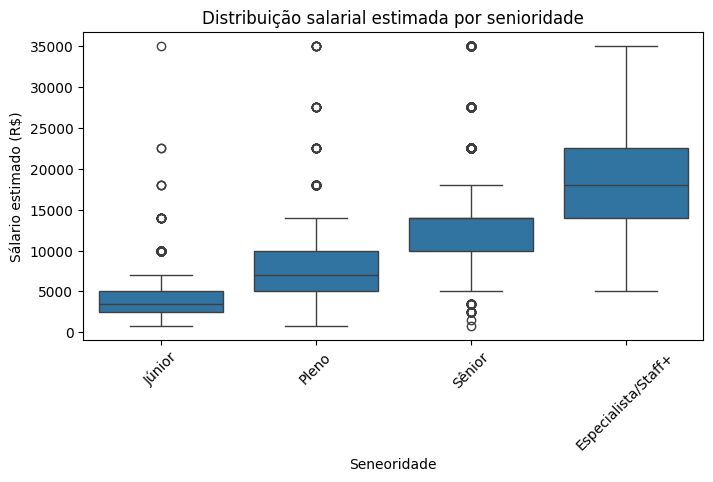

In [21]:
#fizemos um boxplot para ver como está a distribuição salarial de acordo com o nivel de senioridade
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df_com_experiencia,
    x='Nivel',
    y='Salario_medio_faixa'
)
plt.title('Distribuição salarial estimada por senioridade')
plt.xlabel ('Seneoridade')
plt.ylabel ('Sálario estimado (R$)')
plt.xticks(rotation=45)
plt.show()

In [22]:
!pip install geopandas
import geopandas as gpd

In [23]:
#Esse código agrupa e conta quantos profissionais moram em cada estado e organiza o resultado em uma nova tabela.
df_uf = (
    df_com_experiencia ['uf_onde_mora'].value_counts().reset_index()
)
df_uf.columns = ['UF','Quantidade']

In [25]:
#baixamos as fronteiras geográficas dos estados brasileiros e cruzamos esses dados com a sua contagem de profissionais por estado para permitir a criação de um mapa
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

brasil = gpd.read_file(url)

brasil = brasil.merge(
    df_uf,
    left_on='sigla',
    right_on='UF',
    how='left'
)
brasil['Quantidade'] = brasil['Quantidade'].fillna(0)

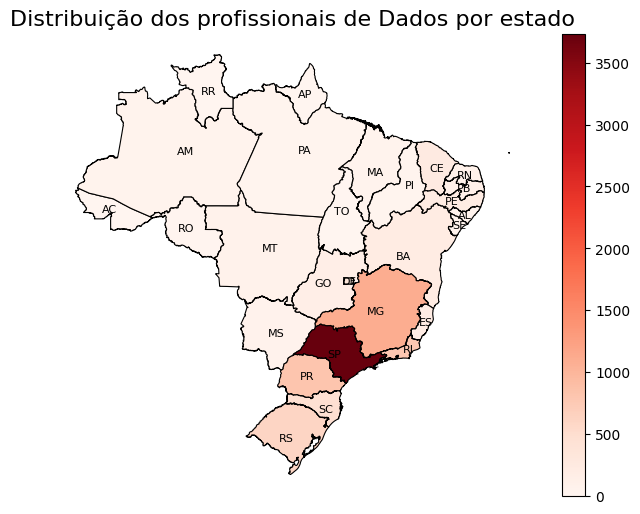

In [28]:
#fizemos um mapa de calor para mostrar a concentração dos profissionais por estado
fig, ax = plt.subplots(figsize=(8, 6))

brasil.plot(
    column='Quantidade',
    cmap='Reds',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    ax=ax
)

# Criar pontos dentro de cada estado
pontos = brasil.copy()
pontos['geometry'] = pontos.geometry.representative_point()

# Adicionar siglas
for idx, row in pontos.iterrows():
    ax.annotate(
        text=row['sigla'],
        xy=(row.geometry.x, row.geometry.y),
        ha='center',
        va='center',
        fontsize=8
    )

ax.set_title(
    'Distribuição dos profissionais de Dados por estado',
    fontsize=16
)

ax.axis('off')

plt.show()

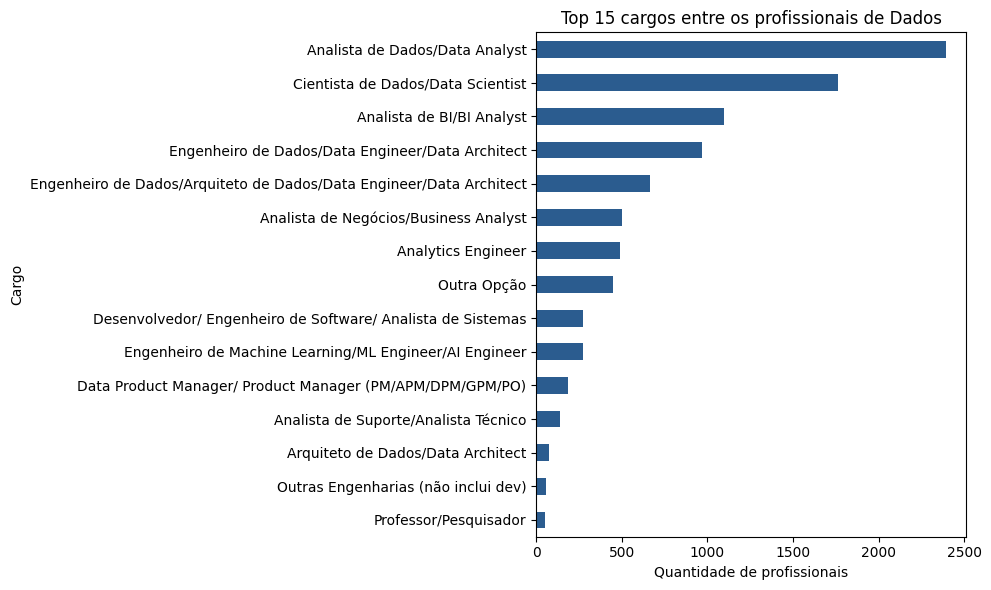

In [31]:
#fizemos um top 15 cargos com mais profissinais
top_cargos = (
    df_com_experiencia['Cargo_Atual']
    .value_counts()
    .head(15)                   # Pega os 15 mais frequentes
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
top_cargos.plot(kind='barh', color='#2b5c8f')

plt.title('Top 15 cargos entre os profissionais de Dados')
plt.xlabel('Quantidade de profissionais')
plt.ylabel('Cargo')

plt.tight_layout()
plt.show()

In [36]:
'''Durante a tratativa dos dados, foi adicionado um sufixo nas colunas indicando o que aquela coluna corresponde
o que facilitou na hora de fazer o mapeamento delas, verifiquei que algumas colunas não eram booleanas,
então retirei elas da lista para facilitar a analise, ja que essas colunas correspondem as colunas booleanas'''
linguagens = [
    col for col in df_com_experiencia.columns
    if '_Linguagem' in col
    and col != 'Quais_das_linguagens_listadas_abaixo_voce_utiliza_no_trabalho_Linguagem'
]

bancos = [
    col for col in df_com_experiencia.columns
    if '_BD' in col
    and col != 'Quais_dos_bancos_de_dados_fontes_de_dados_listados_abaixo_voce_utiliza_no_trabalho_BD'
]

cloud = [
    col for col in df_com_experiencia.columns
    if '_cloud' in col
    and col != 'Dentre_as_opcoes_listadas_qual_sua_Cloud_preferida_cloud'
]

bi = [
    col for col in df_com_experiencia.columns
    if '_BI' in col
    and col != 'Ferramenta_de_BI_utilizada_no_dia_a_dia_BI'
]

etl = [
    col for col in df_com_experiencia.columns
    if '_ETL' in col
    and col != 'Quais_as_ferramentas_tecnologias_de_ETL_que_voce_utiliza_no_trabalho_como_Data_Analyst_ETL'
]

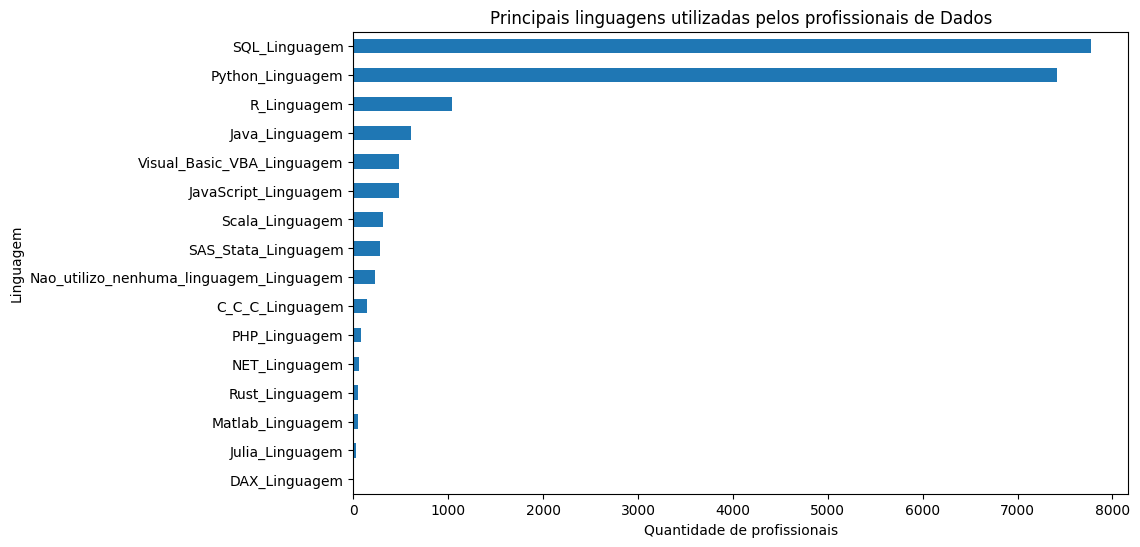

In [37]:
#Aqui verificamos quais são as linguagens mais utilizadas pelos profissionais de dados
top_linguagens = (
    df_com_experiencia[linguagens]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

top_linguagens.plot(kind='barh')

plt.title('Principais linguagens utilizadas pelos profissionais de Dados')
plt.xlabel('Quantidade de profissionais')
plt.ylabel('Linguagem')

plt.show()

In [38]:
'''com a coluna da faixa media salarial criada, realizamos um agrupamento de cargo X nivel X salario'''
cargo_nivel = (
    df_com_experiencia
    .groupby(['Cargo_Atual', 'Nivel'])
    .agg(
        salario_mediano=('Salario_medio_faixa', 'median'),
        quantidade=('Nivel', 'size')
    )
    .reset_index()
)

cargo_nivel.head()

,Cargo_Atual,Nivel,salario_mediano,quantidade
0,Analista de BI/BI Analyst,Especialista/Staff+,14000.0,17
1,Analista de BI/BI Analyst,Júnior,3500.0,352
2,Analista de BI/BI Analyst,Pleno,5000.0,443
3,Analista de BI/BI Analyst,Sênior,10000.0,286
4,Analista de Dados/Data Analyst,Especialista/Staff+,14000.0,58


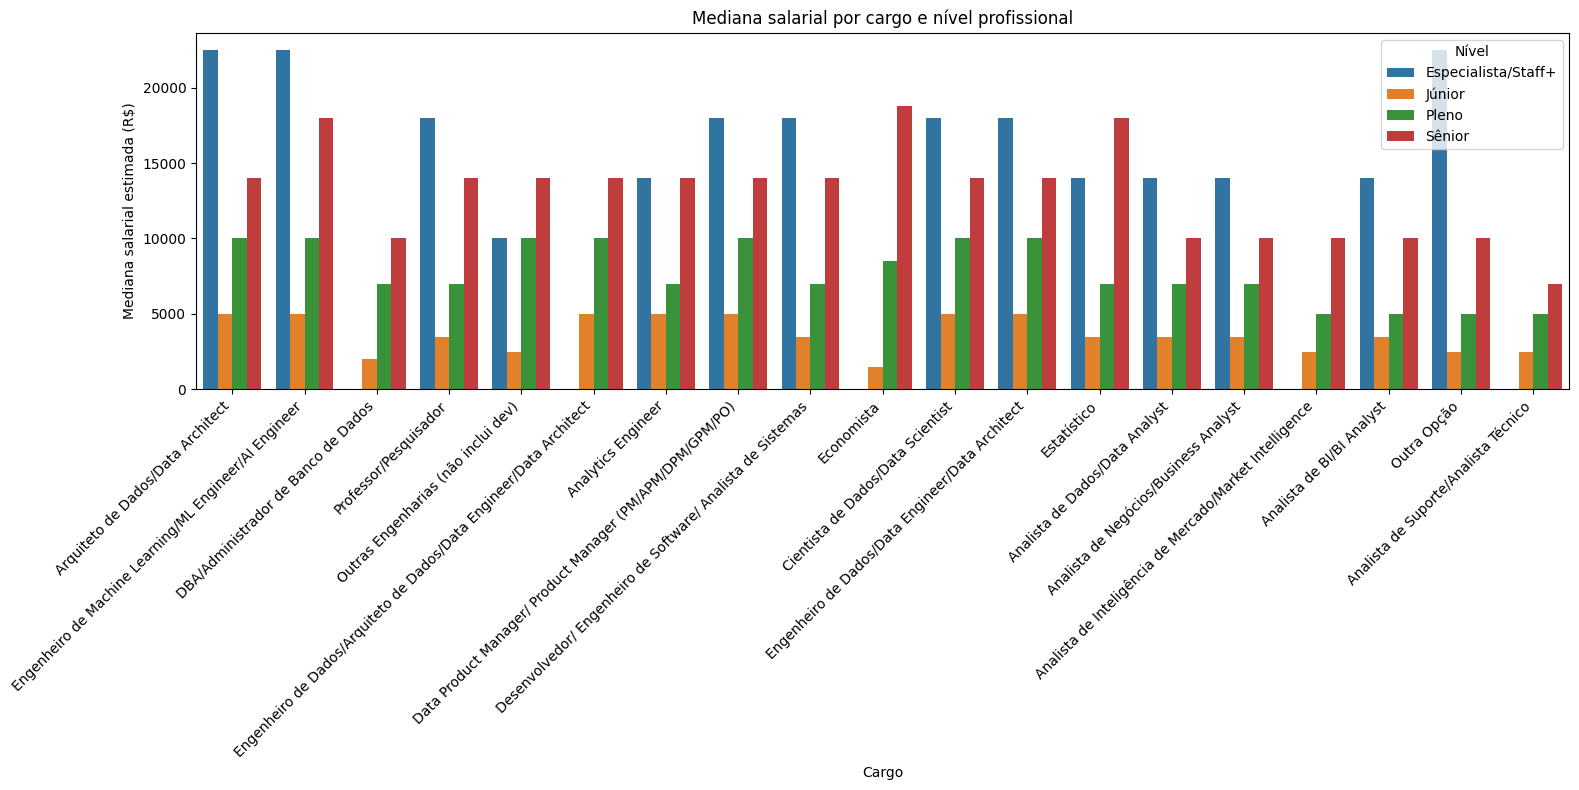

In [45]:
# Agrupa e ordena do MAIOR para o MENOR salário
top_cargos = (
    df_com_experiencia
    .groupby(['Cargo_Atual', 'Nivel'])['Salario_medio_faixa']
    .median()
    .reset_index()
    .sort_values(by='Salario_medio_faixa', ascending=False)
)
#1. Calcula a mediana geral por cargo para definir a ordem exata do eixo X
ordem_cargos = (
    df_com_experiencia
    .groupby('Cargo_Atual')['Salario_medio_faixa']
    .median()
    .sort_values(ascending=False)
    .index
)

# 2. Gera o agrupamento por Cargo e Nível
top_cargos = (
    df_com_experiencia
    .groupby(['Cargo_Atual', 'Nivel'])['Salario_medio_faixa']
    .median()
    .reset_index()
)

# 3. Plota utilizando o parâmetro 'order'
plt.figure(figsize=(16, 8))

sns.barplot(
    data=top_cargos,
    x='Cargo_Atual',
    y='Salario_medio_faixa',
    hue='Nivel',
    order=ordem_cargos # <--- Garante a ordenação decrecente no eixo X
)

plt.title('Mediana salarial por cargo e nível profissional')
plt.xlabel('Cargo')
plt.ylabel('Mediana salarial estimada (R$)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nível')

plt.tight_layout()
plt.show()

In [46]:
modelo_trabalho = (
    df_com_experiencia[
        'Atualmente_qual_a_sua_forma_de_trabalho'
    ]
    .value_counts()
)

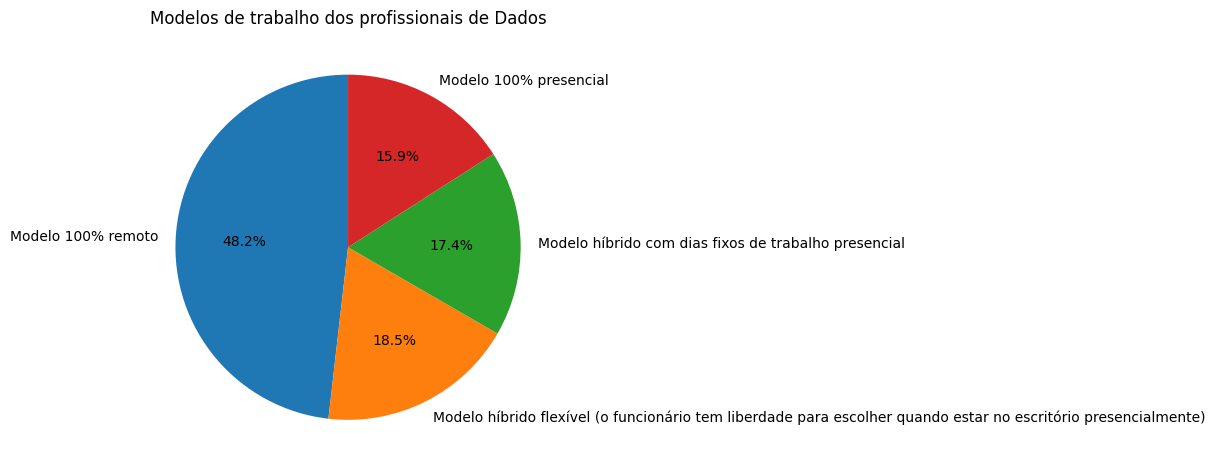

In [51]:
plt.figure(figsize=(10, 8))

modelo_trabalho.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Modelos de trabalho dos profissionais de Dados')

plt.ylabel('')


plt.tight_layout()
plt.show()

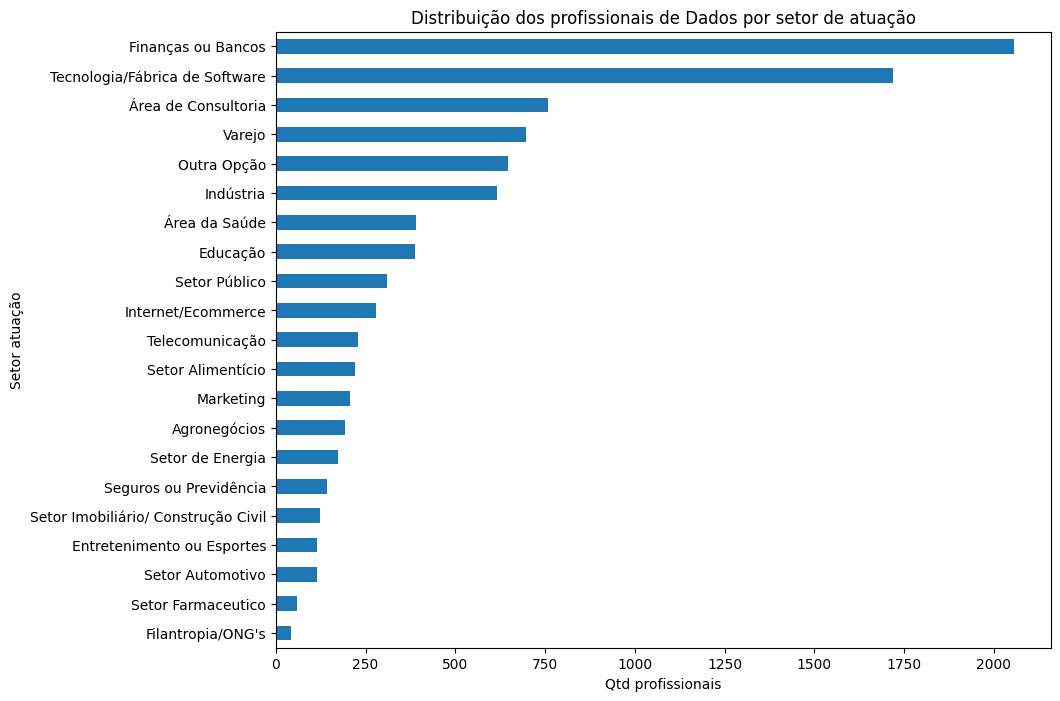

In [52]:
#Visão de onde os profissionais de dados mais atuam
setor_atuacao = (
    df_com_experiencia['Setor'].value_counts().sort_values(ascending=True)
)
plt.figure(figsize=(10,8))
setor_atuacao.plot(kind='barh')
plt.title('Distribuição dos profissionais de Dados por setor de atuação')
plt.xlabel('Qtd profissionais')
plt.ylabel('Setor atuação')
plt.show()

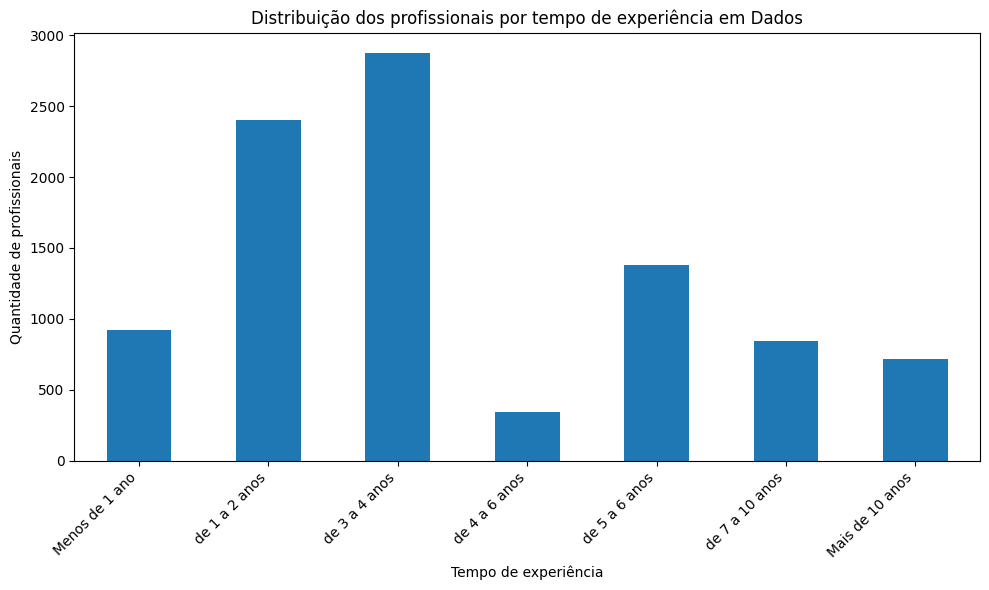

In [55]:
#Grafico para mostrar a distribuição de tempo de experiencia por quantidade de profissionais
ordem_experiencia = [
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 3 a 4 anos',
    'de 4 a 6 anos',
    'de 5 a 6 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos'
]

experiencia = (
    df_com_experiencia[
        'Quanto_tempo_de_experiencia_na_area_de_dados_voce_tem'
    ]
    .value_counts()
    .reindex(ordem_experiencia)
)

plt.figure(figsize=(10,6))

experiencia.plot(kind='bar')

plt.title('Distribuição dos profissionais por tempo de experiência em Dados')
plt.xlabel('Tempo de experiência')
plt.ylabel('Quantidade de profissionais')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


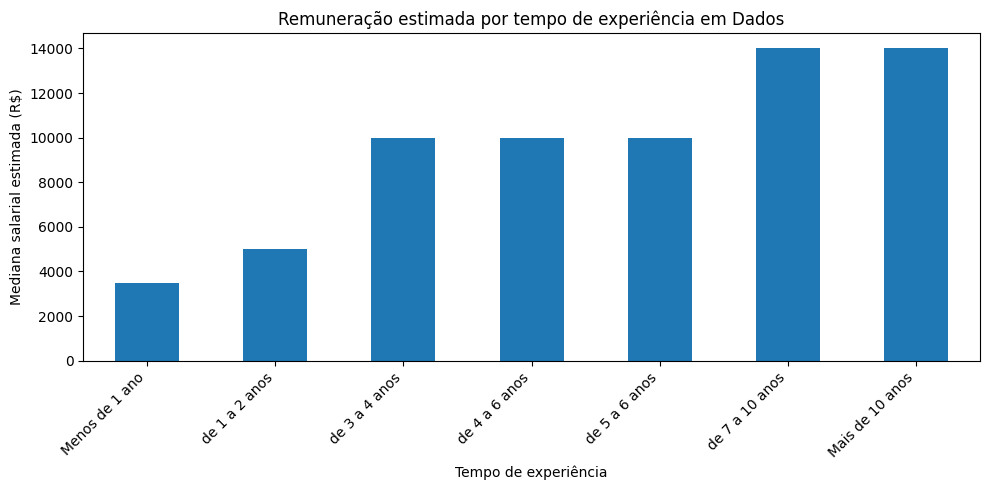

In [57]:
experiencia_salario = (
    df_com_experiencia
    .groupby('Quanto_tempo_de_experiencia_na_area_de_dados_voce_tem')
    ['Salario_medio_faixa']
    .median()
    .reindex(ordem_experiencia)
)

plt.figure(figsize=(10, 5))

ax = experiencia_salario.plot(kind='bar')

plt.title('Remuneração estimada por tempo de experiência em Dados')
plt.xlabel('Tempo de experiência')
plt.ylabel('Mediana salarial estimada (R$)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Respostas das perguntas 1 e 2
Com os gráficos gerados já possuimos dados suficientes para responder as perguntas 1 e 2:
**1 - Como está estruturado o mercado brasileiro de Dados?**
A análise da base demonstra que o mercado brasileiro de Dados é formado principalmente por profissionais de nível Sênior e Pleno, seguidos pelos níveis Júnior e Especialista/Staff. A maior concentração geográfica está em São Paulo, enquanto os setores Financeiro e Bancário apresentam a maior quantidade de profissionais de Dados, seguidos por Tecnologia e Fábrica de Software.
Em relação às competências técnicas, SQL é a linguagem mais utilizada, seguida por Python. Quanto à experiência profissional, a maior concentração dos entrevistados possui entre 1 e 4 anos de experiência na área. O mercado também apresenta forte presença de modelos de trabalho remoto e híbrido, enquanto o modelo 100% presencial apresenta a menor participação.
Dessa forma, o mercado brasileiro de Dados analisado apresenta uma forte concentração de profissionais Plenos e Seniores, principalmente nos setores financeiro, bancário e tecnológico, com ampla utilização de SQL e Python e predominância de modelos de trabalho remoto e híbrido.
**2- Quais perfis profissionais são mais valorizados pelo mercado?**
A análise da remuneração estimada indica que a experiência profissional e a senioridade estão associadas a níveis mais elevados de remuneração. De modo geral, observa-se uma tendência de aumento da remuneração conforme aumenta o tempo de experiência em Dados.
A análise por cargo também evidencia diferenças relevantes entre os profissionais. Embora o cargo de Analista de Dados esteja entre os mais comuns na base, sua remuneração estimada está entre as menores quando comparada aos 15 cargos analisados. Em contrapartida, profissionais classificados como Staff/Especialistas apresentam algumas das maiores remunerações estimadas.
Os resultados sugerem, portanto, que os perfis mais valorizados financeiramente são aqueles que combinam maior experiência, maior nível de senioridade e atuação em cargos mais especializados.



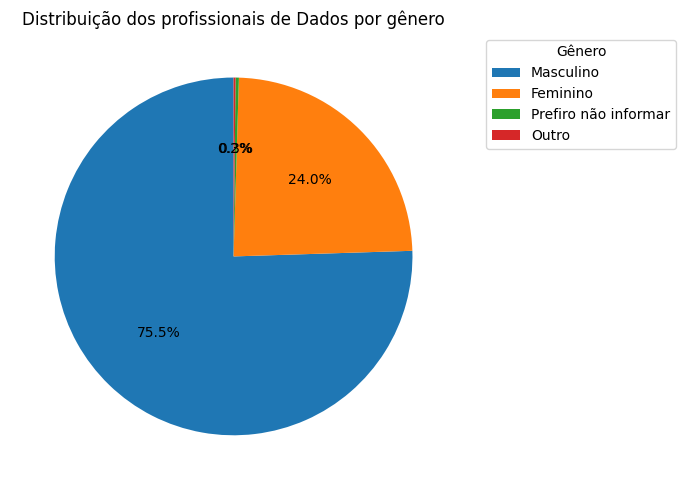

In [59]:
genero = (
    df_com_experiencia['Genero']
    .value_counts()
)

plt.figure(figsize=(10, 5))

genero.plot(
    kind='pie',
    labels=None,
    startangle=90,
    autopct='%1.1f%%'  # Mantido apenas um autopct
)

plt.title('Distribuição dos profissionais de Dados por gênero')
plt.ylabel('')

plt.legend(
    title='Gênero',
    labels=genero.index,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

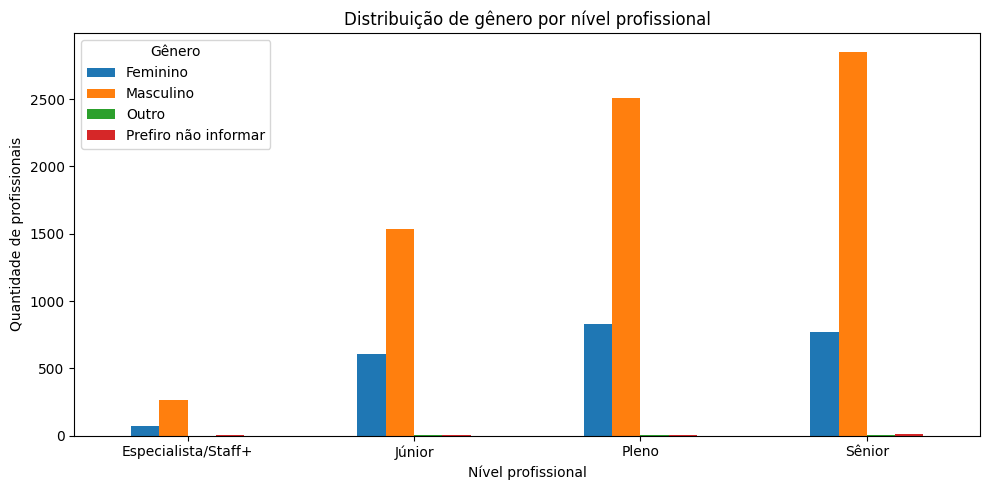

In [60]:
nivel_genero = pd.crosstab(
    df_com_experiencia['Nivel'],
    df_com_experiencia['Genero']
)

nivel_genero.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Distribuição de gênero por nível profissional')
plt.xlabel('Nível profissional')
plt.ylabel('Quantidade de profissionais')
plt.xticks(rotation=0)
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

In [61]:
salario_genero_nivel = (
    df_com_experiencia
    .groupby(['Nivel', 'Genero'])['Salario_medio_faixa']
    .median()
    .reset_index()
)

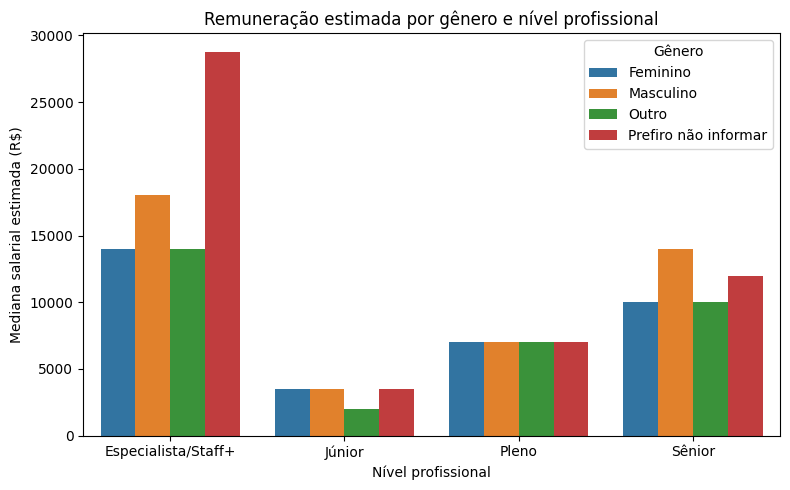

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=salario_genero_nivel,
    x='Nivel',
    y='Salario_medio_faixa',
    hue='Genero'
)

plt.title('Remuneração estimada por gênero e nível profissional')
plt.xlabel('Nível profissional')
plt.ylabel('Mediana salarial estimada (R$)')
plt.legend(title='Gênero')

plt.tight_layout()
plt.show()

In [63]:
df_com_experiencia[
    (df_com_experiencia['Nivel'] == 'Especialista/Staff+') &
    (df_com_experiencia['Genero'] == 'Prefiro não informar')
][[
    'Genero',
    'Nivel',
    'Faixa_salarial',
    'Salario_medio_faixa'
]].sort_values('Salario_medio_faixa')

,Genero,Nivel,Faixa_salarial,Salario_medio_faixa
15713,Prefiro não informar,Especialista/Staff+,de R$ 20.001/mês a R$ 25.000/mês,22500.0
15689,Prefiro não informar,Especialista/Staff+,de R$ 30.001/mês a R$ 40.000/mês,35000.0


In [64]:
'''Vimos que o genero "prefiro nao informar" foi muito descrepante da area de especialistas/Staff+, então verificamos que
tinha apenas 2 casos que estavam dando esse outlier, entãod decidimos trabalhar so com os generos predominantes, masculinos e femininos"'''
df_genero_comparacao = df_com_experiencia[
    df_com_experiencia['Genero'].isin(['Masculino', 'Feminino'])
].copy()

In [65]:
salario_genero_nivel = (
    df_genero_comparacao
    .groupby(['Nivel', 'Genero'])['Salario_medio_faixa']
    .median()
    .reset_index()
)

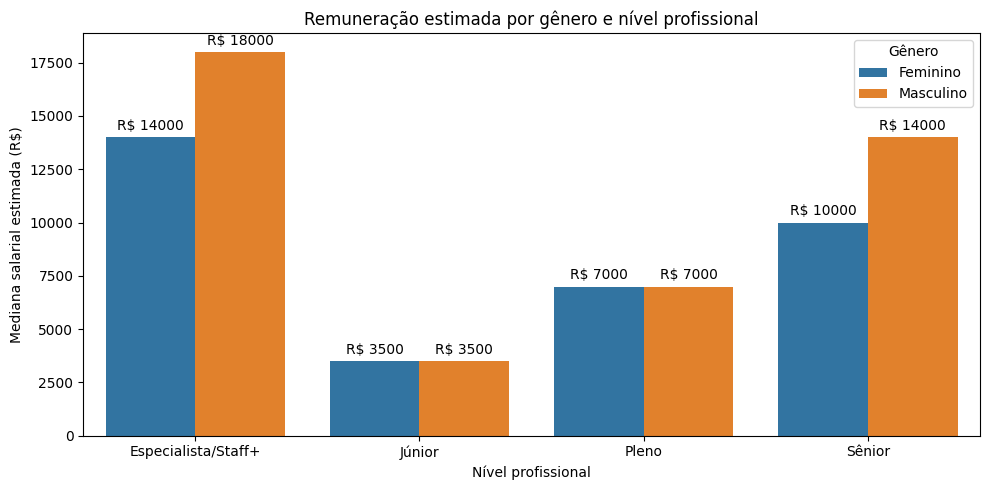

In [67]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=salario_genero_nivel,
    x='Nivel',
    y='Salario_medio_faixa',
    hue='Genero'
)

plt.title('Remuneração estimada por gênero e nível profissional')
plt.xlabel('Nível profissional')
plt.ylabel('Mediana salarial estimada (R$)')
plt.legend(title='Gênero')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='R$ %.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

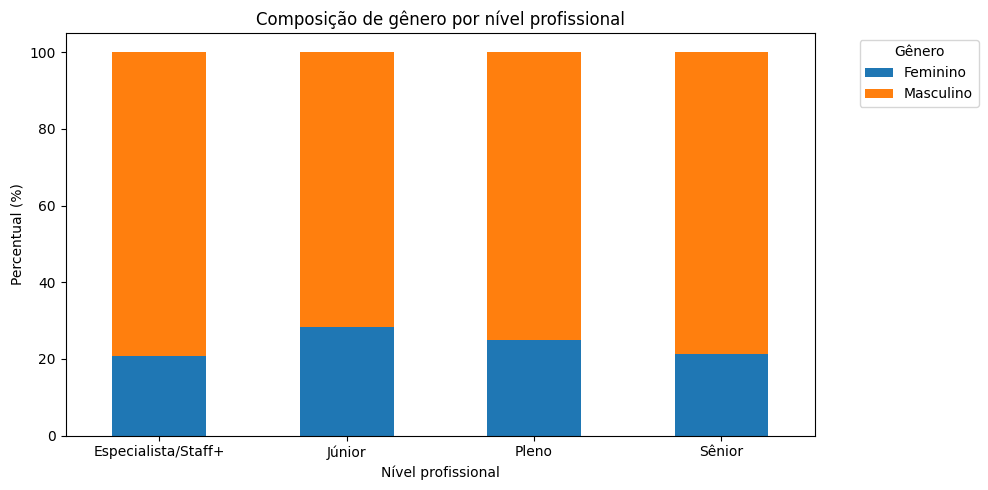

In [69]:
nivel_genero_pct = pd.crosstab(
    df_com_experiencia['Nivel'],
    df_genero_comparacao['Genero'],
    normalize='index'
) * 100

nivel_genero_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Composição de gênero por nível profissional')
plt.xlabel('Nível profissional')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Resposta da Pergunta 3
Qual é o cenário de diversidade de gênero nas carreiras de dados?
A análise de dados revela uma disparidade estrutural de gênero no mercado brasileiro, evidenciada pela baixa representatividade feminina geral (24% frente a 75,5% masculina) e por um nítido efeito de afunilamento ao longo da carreira, no qual a presença de mulheres cai de 28,4% no nível Júnior para 21,2% nos cargos Sênior e Especialista/Staff+. Além disso, embora haja paridade salarial nos níveis de entrada e pleno, observa-se o surgimento de uma expressiva diferença no topo da senioridade, onde homens chegam a receber medianas salariais de até 40% a mais no nível Sênior (R$ 14.000 vs. R$ 10.000) e 28,5% a mais como Especialistas (R$ 18.000 vs. R$ 14.000), demonstrando a existência de barreiras de retenção e progressão financeira para as profissionais do setor.


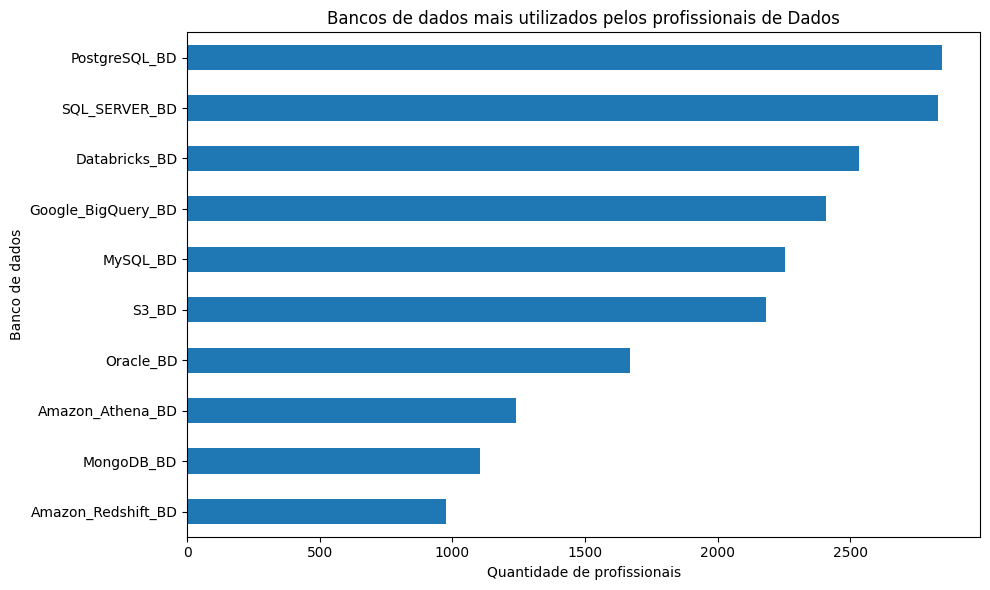

In [70]:
top_bancos = (
    df_com_experiencia[bancos]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(10, 6))

top_bancos.plot(kind='barh')

plt.title('Bancos de dados mais utilizados pelos profissionais de Dados')
plt.xlabel('Quantidade de profissionais')
plt.ylabel('Banco de dados')

plt.tight_layout()
plt.show()

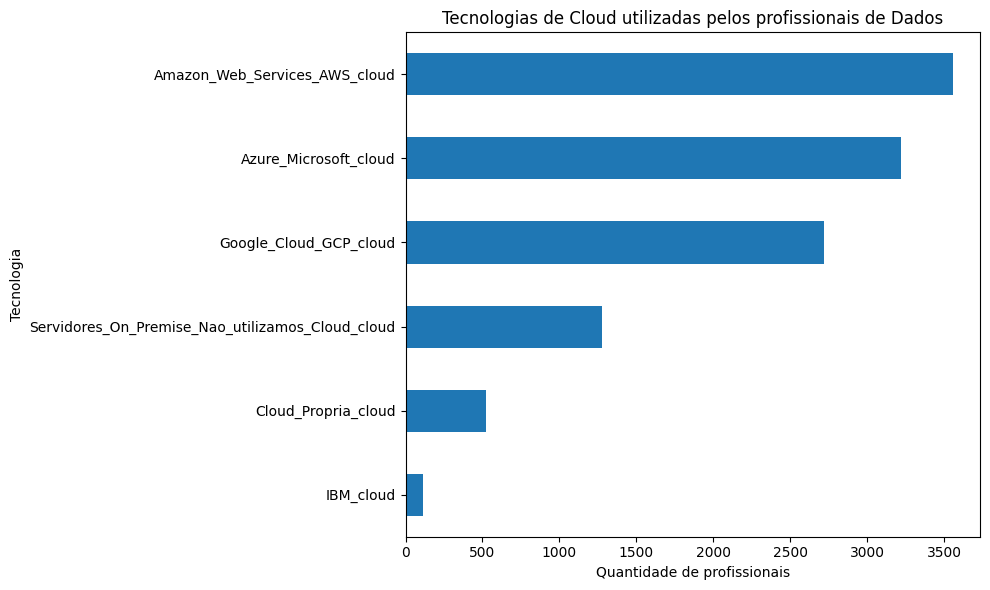

In [71]:
top_cloud = (
    df_com_experiencia[cloud]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

top_cloud.plot(kind='barh')

plt.title('Tecnologias de Cloud utilizadas pelos profissionais de Dados')
plt.xlabel('Quantidade de profissionais')
plt.ylabel('Tecnologia')

plt.tight_layout()
plt.show()

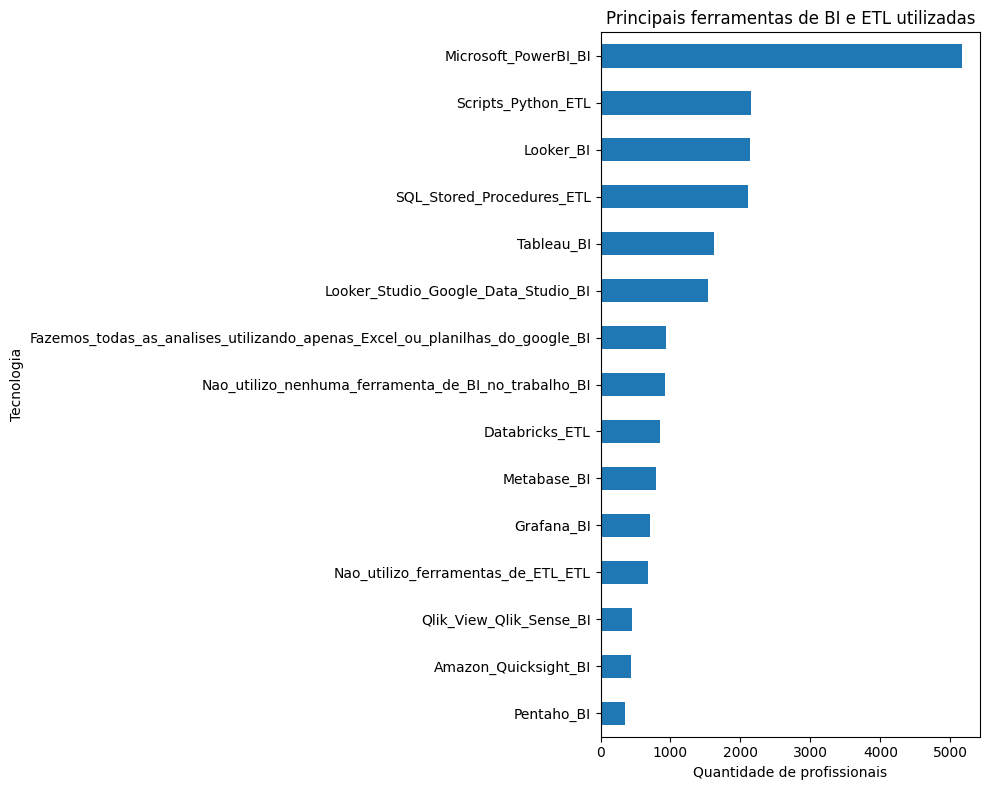

In [72]:
tecnologias_bi_etl = bi + etl

top_bi_etl = (
    df_com_experiencia[tecnologias_bi_etl]
    .sum()
    .sort_values(ascending=True)
    .tail(15)
)

plt.figure(figsize=(10, 8))

top_bi_etl.plot(kind='barh')

plt.title('Principais ferramentas de BI e ETL utilizadas')
plt.xlabel('Quantidade de profissionais')
plt.ylabel('Tecnologia')

plt.tight_layout()
plt.show()

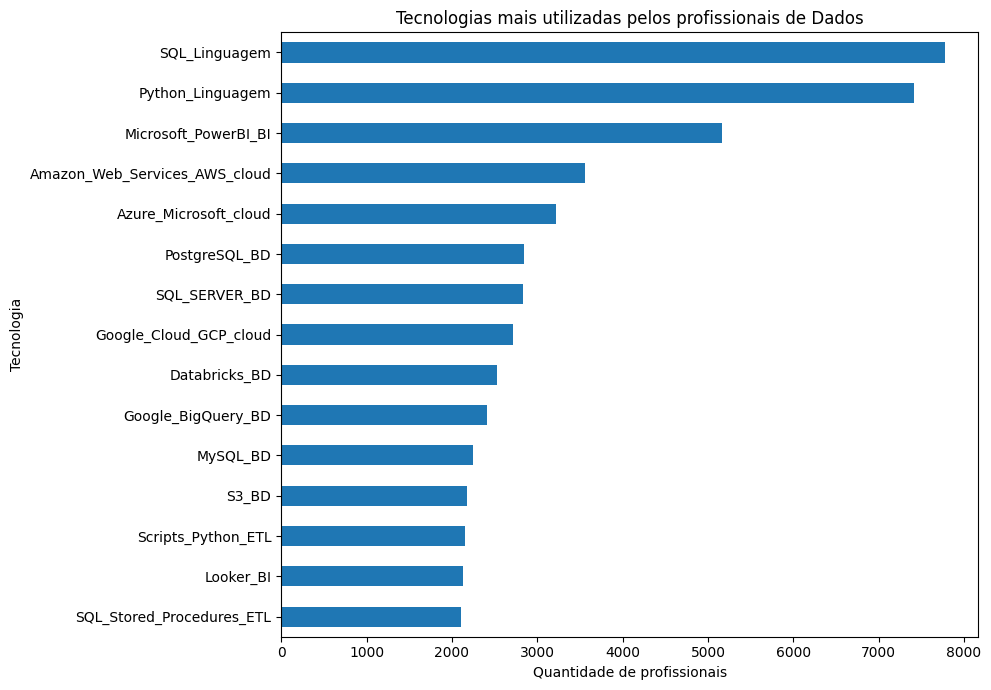

In [73]:
tecnologias = {}

for col in linguagens + bancos + cloud + bi + etl:
    tecnologias[col] = df_com_experiencia[col].sum()

tecnologias = (
    pd.Series(tecnologias)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))
tecnologias.sort_values().plot(kind='barh')

plt.title('Tecnologias mais utilizadas pelos profissionais de Dados')
plt.xlabel('Quantidade de profissionais')
plt.ylabel('Tecnologia')

plt.tight_layout()
plt.show()

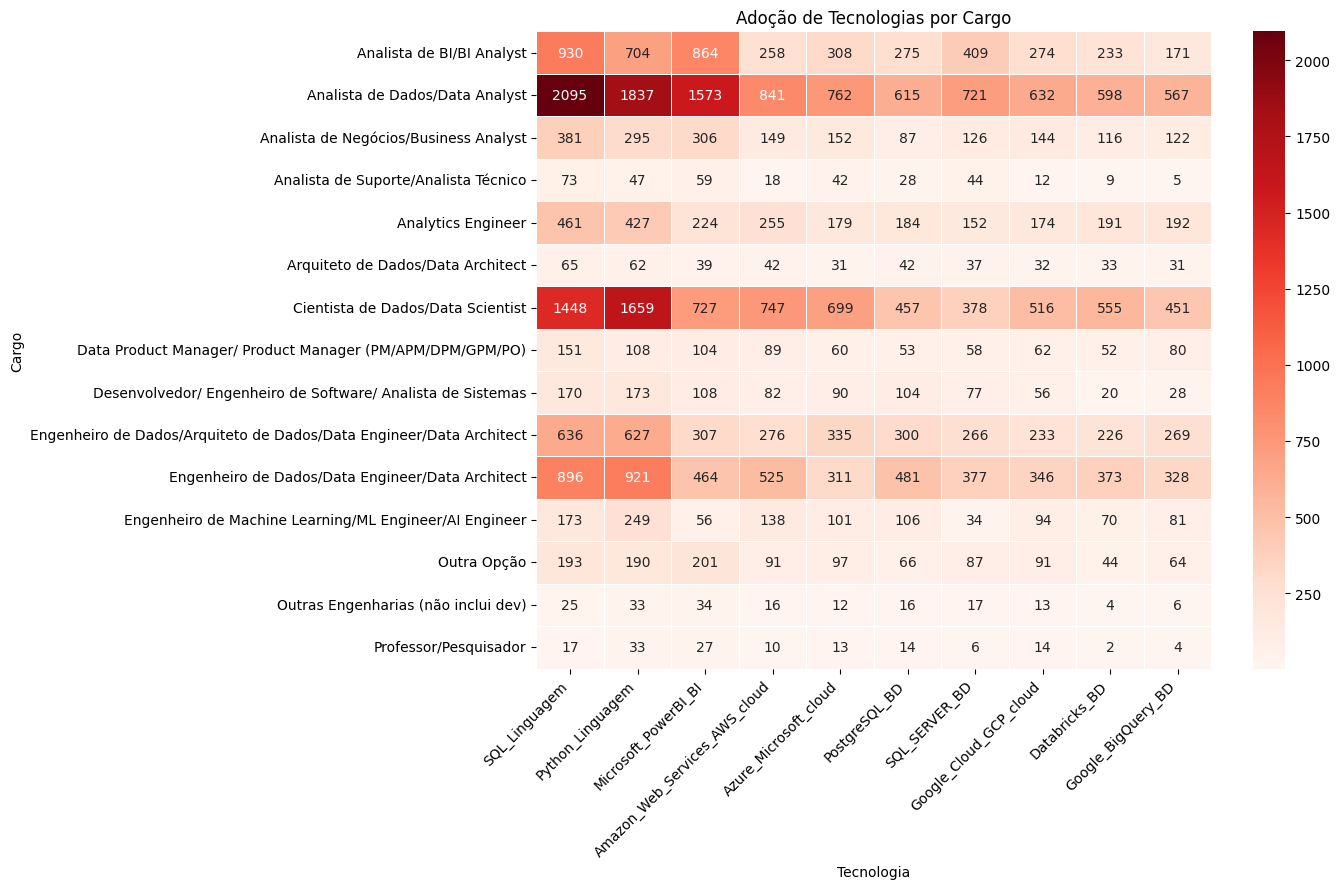

In [75]:
todas_tecnologias = linguagens + bancos + cloud + bi + etl

top_10_tecnologias = (
    df_com_experiencia[todas_tecnologias]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)


dados_heatmap = df_com_experiencia[
    ['Cargo_Atual'] + list(top_10_tecnologias)
].copy()

heatmap_cargo = (
    dados_heatmap
    .groupby('Cargo_Atual')[top_10_tecnologias]
    .sum()
)

top_cargos = (
    df_com_experiencia['Cargo_Atual']
    .value_counts()
    .head(15)
    .index
)

heatmap_cargo = heatmap_cargo.loc[
    heatmap_cargo.index.intersection(top_cargos)
]

plt.figure(figsize=(14, 9))

sns.heatmap(
    heatmap_cargo,
    annot=True,
    fmt='.0f',
    cmap='Reds',
    linewidths=0.5
)

plt.title('Adoção de Tecnologias por Cargo')
plt.xlabel('Tecnologia')
plt.ylabel('Cargo')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Resposta da pergunta 4
Quais tecnologias apresentam maior adoção entre os profissionais?
As tecnologias de maior adoção no mercado brasileiro estruturam-se em um stack analítico bem definido: SQL e Python possuem liderança absoluta e uso transversal em quase todos os cargos (com picos em Analistas e Cientistas de Dados), enquanto o Microsoft Power BI domina a camada de visualização e apoio à decisão negócios; já na infraestrutura de retaguarda, a AWS lidera o segmento de nuvem (seguida por Azure e GCP), sustentando o processamento em bancos de dados relacionais (PostgreSQL e SQL Server) e plataformas de Big Data/Warehouse (Databricks e BigQuery), que concentram sua utilização principalmente entre as equipes de Engenharia e Ciência de Dados.

In [76]:
#verificando a informação das colunas que podemos utilizar para ver a adoção da IA
df_com_experiencia[
    [
        'AI_Generativa_e_uma_prioridade_em_sua_empresa',
        'Tipos_de_uso_de_AI_Generativa_e_LLMs_na_empresa',
        'Motivos_que_levam_a_empresa_a_nao_usar_AI_Genrativa_e_LLMs',
        'Qual_o_tipo_de_uso_de_AI_Generativa_e_LLMs_na_empresa'
    ]
].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9482 entries, 0 to 17433
Data columns (total 4 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   AI_Generativa_e_uma_prioridade_em_sua_empresa               0 non-null      float64
 1   Tipos_de_uso_de_AI_Generativa_e_LLMs_na_empresa             0 non-null      float64
 2   Motivos_que_levam_a_empresa_a_nao_usar_AI_Genrativa_e_LLMs  0 non-null      float64
 3   Qual_o_tipo_de_uso_de_AI_Generativa_e_LLMs_na_empresa       9035 non-null   object 
dtypes: float64(3), object(1)
memory usage: 628.4+ KB


In [79]:
df_com_experiencia[
    'Qual_o_tipo_de_uso_de_AI_Generativa_e_LLMs_na_empresa'
].value_counts().head(100)

,count
Qual_o_tipo_de_uso_de_AI_Generativa_e_LLMs_na_empresa,
"Colaboradores utilizando soluções baseadas em AI Generativa (como o ChatGPT por exemplo) de forma independente, com o objetivo de melhorar sua produtividade no dia a dia, sem um direcionamento centralizado.",1793
"Não tenho visto soluções de IA Generatica e LLMs sendo tradadas como prioridade pela empresa e pessoas, os poucos casos de uso são isolados ou ainda estão muito no início.",891
Não sei opinar.,666
"Colaboradores utilizando soluções baseadas em AI Generativa (como o ChatGPT, Copilot, Gemini, Claude, Perplexity por exemplo) de forma independente, com o objetivo de melhorar sua produtividade no dia a dia, sem um direcionamento centralizado.",459
"Uma ou mais equipes testando e aplicando soluções de AI Generativa e LLMs, com o objetivo de propor melhorias e inovações para impulsionar a diferenciação de produtos oferecidos para os clientes finais (exemplo: novos recursos, produtos, serviços etc)",391
...,...
"Equipes de desenvolvimento utilizando soluções no estilo Copilot (Github Copilot, AWS CodeWhisperer etc) para obter mais produtividade no processo de desenvolvimento., Existe um direcionamento centralizado para que colaboradores utilizem soluções baseadas em AI Generativa (como o ChatGPT por exemplo), incluindo apoio nos custos das ferramentas., Uma ou mais equipes testando e aplicando soluções de AI Generativa e LLMs, com o objetivo de propor melhorias e inovações para impulsionar a diferenciação de produtos oferecidos para os clientes finais (exemplo: novos recursos, produtos, serviços etc), Uma ou mais equipes testando e aplicando soluções de AI Generativa e LLMs, com o objetivo de aumentar a eficiencia de processos internos (como produtividade das equipes internas, ou melhoria de processos existentes).",9
"Uma ou mais equipes testando e aplicando soluções de AI Generativa e LLMs, com o objetivo de propor melhorias e inovações para impulsionar a diferenciação de produtos oferecidos para os clientes finais (exemplo: novos recursos, produtos, serviços etc), Colaboradores utilizando soluções baseadas em AI Generativa (como o ChatGPT, Copilot, Gemini, Claude, Perplexity por exemplo) de forma independente, com o objetivo de melhorar sua produtividade no dia a dia, sem um direcionamento centralizado.",9
"Uma ou mais equipes testando e aplicando soluções de AI Generativa e LLMs, com o objetivo de aumentar a eficiencia de processos internos (como produtividade das equipes internas, ou melhoria de processos existentes)., Colaboradores utilizando soluções baseadas em AI Generativa (como o ChatGPT por exemplo) de forma independente, com o objetivo de melhorar sua produtividade no dia a dia, sem um direcionamento centralizado., Equipes de desenvolvimento utilizando soluções no estilo Copilot (Github Copilot, AWS CodeWhisperer etc) para obter mais produtividade no processo de desenvolvimento.",9


In [80]:
#Classificando alguns trechos das repostas
coluna_ia = 'Qual_o_tipo_de_uso_de_AI_Generativa_e_LLMs_na_empresa'


def classificar_ia(resposta):

    if pd.isna(resposta):
        return 'Sem resposta'

    if 'Não sei opinar' in resposta:
        return 'Não sabe opinar'

    if 'Não tenho visto soluções' in resposta:
        return 'Baixa ou inicial'

    if 'principal frente do negócio' in resposta:
        return 'IA como estratégia principal'

    if 'direcionamento centralizado' in resposta:
        return 'Uso direcionado pela empresa'

    if 'aumentar a eficiencia de processos internos' in resposta:
        return 'Eficiência de processos internos'

    if 'diferenciação de produtos' in resposta:
        return 'Inovação e produtos'

    if 'desenvolvimento utilizando soluções de AI para código' in resposta:
        return 'Desenvolvimento de software'

    if 'utilizando soluções baseadas em AI Generativa' in resposta:
        return 'Uso individual para produtividade'

    return 'Outros'


df_com_experiencia['Categoria_IA'] = (
    df_com_experiencia[coluna_ia]
    .apply(classificar_ia)
)

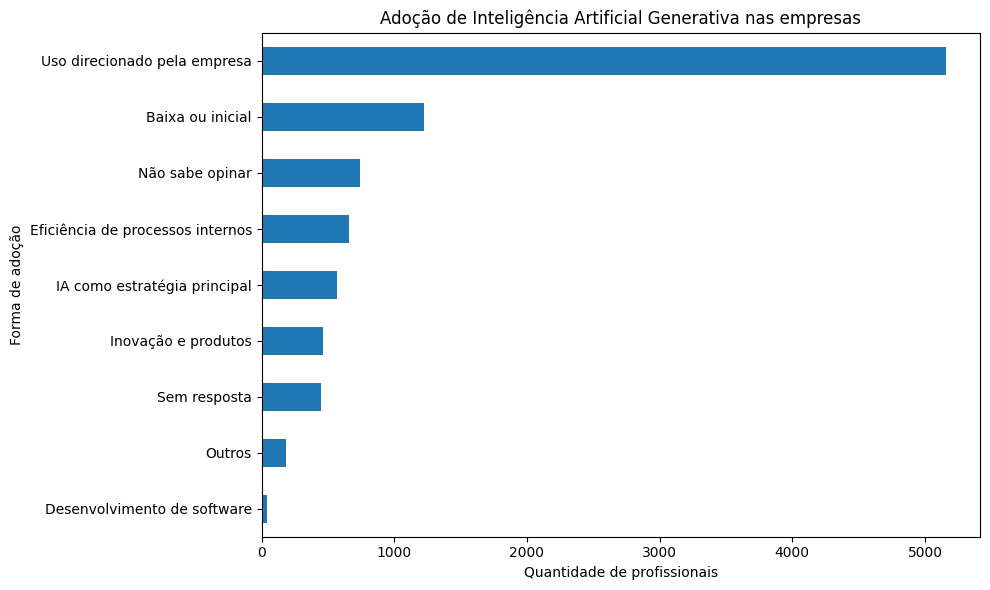

In [81]:
adocao_ia = (
    df_com_experiencia['Categoria_IA']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

adocao_ia.plot(kind='barh')

plt.title('Adoção de Inteligência Artificial Generativa nas empresas')
plt.xlabel('Quantidade de profissionais')
plt.ylabel('Forma de adoção')

plt.tight_layout()
plt.show()

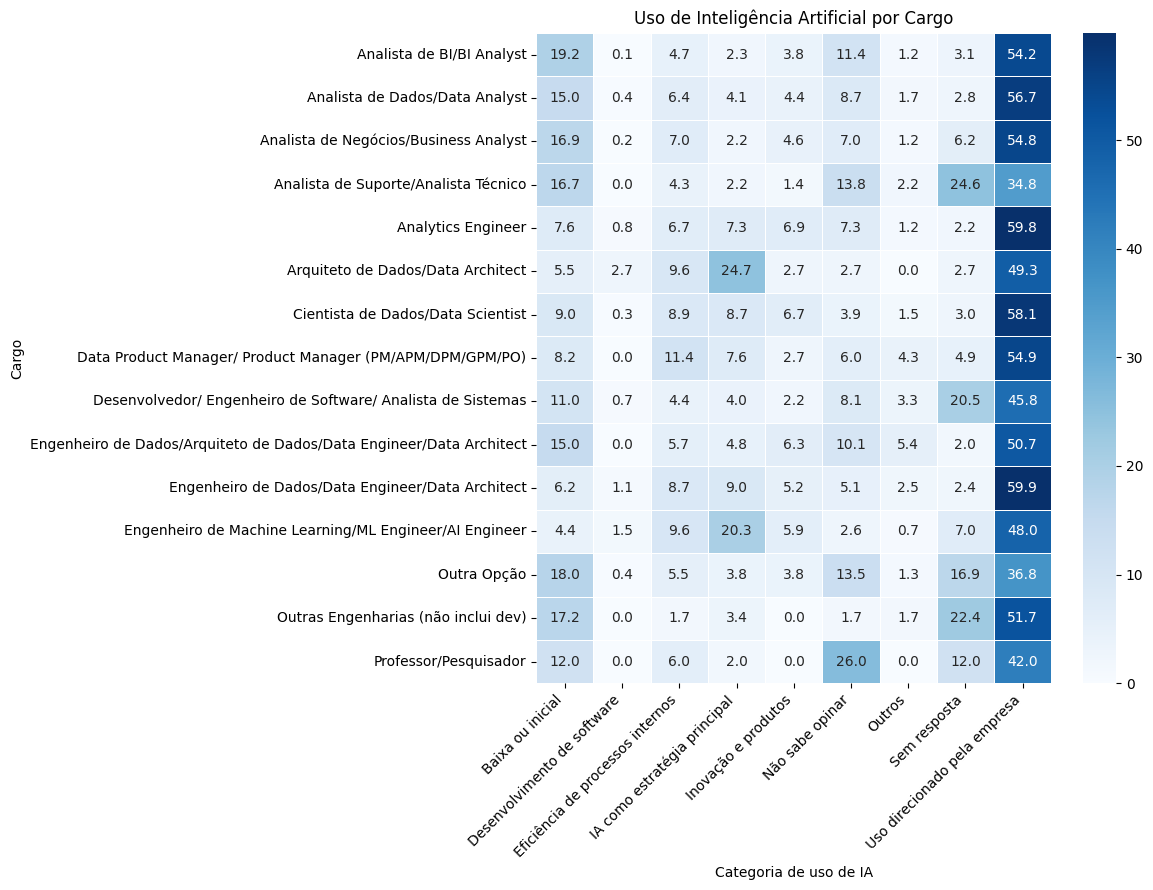

In [89]:
df_ia_cargo = df_com_experiencia[
    df_com_experiencia['Cargo_Atual'].isin(top_cargos)
].copy()

# Cruzar cargo x categoria de IA
ia_cargo = pd.crosstab(
    df_ia_cargo['Cargo_Atual'],
    df_ia_cargo['Categoria_IA'],
    normalize='index'
) * 100

# Heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    ia_cargo,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Uso de Inteligência Artificial por Cargo')
plt.xlabel('Categoria de uso de IA')
plt.ylabel('Cargo')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

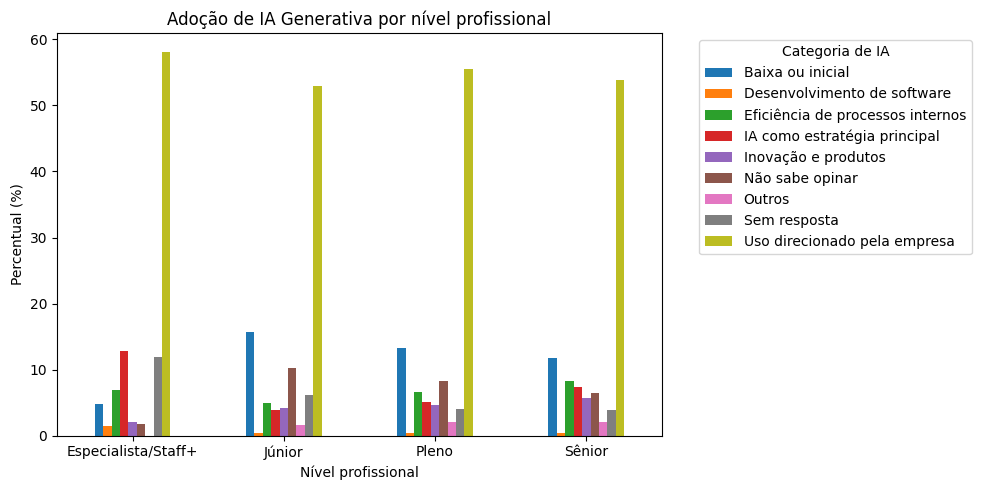

In [87]:
ia_por_nivel = pd.crosstab(
    df_com_experiencia['Nivel'],
    df_com_experiencia['Categoria_IA'],
    normalize='index'
) * 100

ia_por_nivel.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Adoção de IA Generativa por nível profissional')
plt.xlabel('Nível profissional')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

plt.legend(
    title='Categoria de IA',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

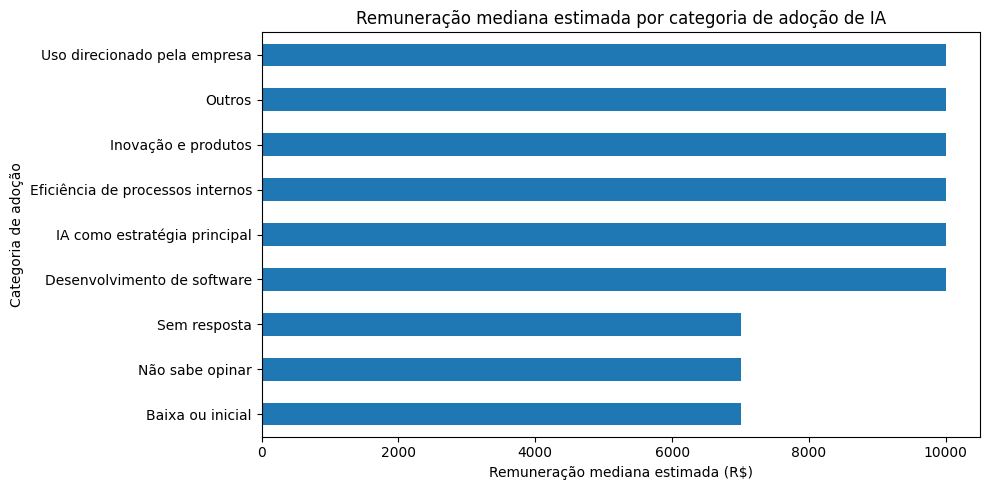

In [91]:
remuneracao_ia = (
    df_com_experiencia
    .groupby('Categoria_IA')['Salario_medio_faixa']
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 5))

remuneracao_ia.plot(kind='barh')

plt.title('Remuneração mediana estimada por categoria de adoção de IA')
plt.xlabel('Remuneração mediana estimada (R$)')
plt.ylabel('Categoria de adoção')

plt.tight_layout()
plt.show()

# Respota da pergunta 5
Qual é o índice de adoção de Inteligência Artificial e seu impacto?
A Inteligência Artificial Generativa consolidou-se no mercado corporativo sob um modelo de governança centralizada, no qual a modalidade "Uso direcionado pela empresa" lidera isoladamente com mais de 5.000 menções, englobando mais de 50% dos profissionais em quase todos os cargos e níveis de senioridade (com pico de 59,9% entre Engenheiros de Dados e 58% no nível Especialista/Staff+). Enquanto profissionais em início de carreira (Júnior e Pleno) registram taxas mais expressivas de adoção "Baixa ou inicial" (entre 13% e 16%), o uso da IA voltado para "Inovação e produtos" ou como "Estratégia principal" concentra-se no topo da cadeia técnica, liderado por Arquitetos de Dados (24,7%) e Engenheiros de Machine Learning/AI (20,3%).

Impactos
O impacto da maturidade no uso da IA reflete-se de forma direta na valorização financeira dos profissionais de dados. Aqueles inseridos em ambientes que utilizam a tecnologia de forma estruturada — seja por direcionamento corporativo, foco em eficiência de processos, desenvolvimento de software ou como pilar estratégico — alcançam o patamar máximo de remuneração mediana estimada em R$ 10.000,00. Em contrapartida, profissionais com adoção baixa, inicial ou inexistente apresentam rendimento médio estagnado na faixa de R$ 7.000,00, evidenciando um ganho financeiro de aproximadamente 42% associado à integração prática e estratégica da IA na rotina de trabalho.

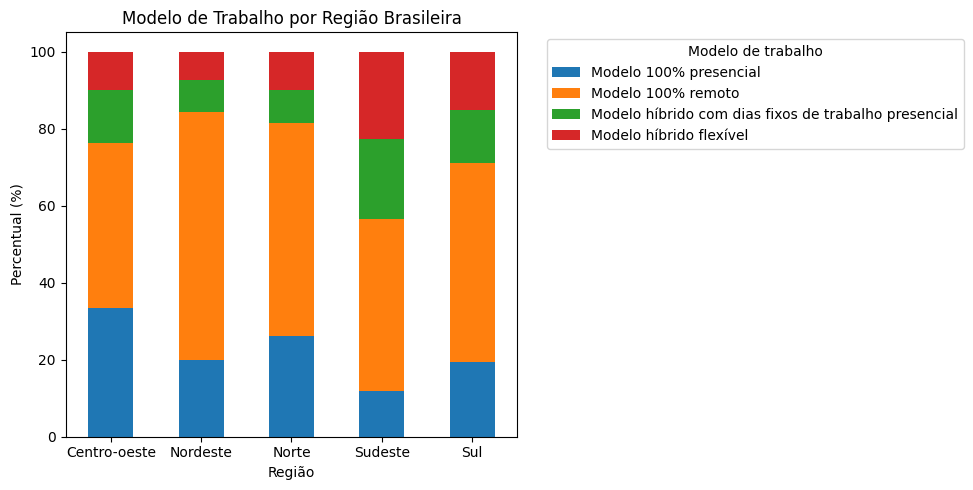

In [94]:
regiao_modelo = pd.crosstab(
    df_com_experiencia['Regiao_onde_mora'],
    df_com_experiencia['Atualmente_qual_a_sua_forma_de_trabalho'],
    normalize='index'
) * 100

# Gráfico
regiao_modelo.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Modelo de Trabalho por Região Brasileira')
plt.xlabel('Região')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

plt.legend(
    title='Modelo de trabalho',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Resposta da pergunta 6

Existem diferenças relevantes entre regiões, senioridades ou modelos de trabalho?
As análises evidenciam diferenças marcantes e estruturais quando observamos a distribuição dos profissionais, seus salários e os formatos de atuação no mercado de dados.

No âmbito regional, observa-se uma forte concentração geográfica dos profissionais no estado de São Paulo, seguido por Minas Gerais e Paraná, enquanto as regiões Norte, Nordeste e Centro-Oeste apresentam volumes expressivamente menores. Essa distribuição influencia diretamente a adoção dos modelos de trabalho: as regiões Nordeste, Norte e Sul registram a maior prevalência do formato 100% remoto (entre 50% e 60% do mercado local). Em contrapartida, o Sudeste destaca-se por concentrar a maior taxa de modelos híbridos (ultrapassando 40%), além de apresentar o menor índice de trabalho 100% presencial (cerca de 12%), modalidade que atinge seu pico na região Centro-Oeste (próxima a 35%).

No que tange à senioridade, a progressão da carreira reflete um salto salarial consistente e direto a cada nível de experiência. A mediana remuneratória parte de aproximadamente R$ 3.500,00 para profissionais Júniores, evolui para cerca de R$ 7.000,00 no nível Pleno, alcança R$ 12.000,00 entre Sêniores e atinge a faixa de R$ 18.000,00 no nível Especialista/Staff+. Além da elevação do patamar médio, os níveis mais avançados, especialmente Especialista/Staff+, exibem uma amplitude salarial consideravelmente maior, embora existam outliers de alta remuneração (com teto de R$ 35.000,00) distribuídos pontualmente desde o nível Júnior.

# Resposta da pergunta 7
Quais oportunidades e desafios podem ser identificados para empresas que desejam investir em Dados e Inteligência Artificial?

Oportunidades Estratégicas
O investimento em Dados e IA oferece ganhos diretos de produtividade e maturidade analítica, com o mercado já consolidado em stacks maduros (como SQL, Python, Power BI e AWS) e no uso de IA direcionado pela empresa, o que eleva a eficiência operacional e a valorização das equipes. Além disso, a forte adesão ao trabalho 100% remoto fora do eixo Sudeste (superando 50% nas regiões Norte, Nordeste e Sul) possibilita às empresas captar talentos em todo o país, escalando suas iniciativas de dados sem restrições geográficas.

Desafios Operacionais e Financeiros
Por outro lado, as empresas enfrentam custos crescentes e gargalos na retenção de perfis seniores, refletidos na forte progressão salarial que salta de uma mediana de R$ 3.500,00 (Júnior) para R$ 18.000,00 (Especialista/Staff+). Esse cenário é agravado pela concentração de profissionais no Sudeste e pela escassez de habilidades avançadas, já que o uso da IA como estratégia principal ou em inovação ainda fica restrito a cargos altamente especializados (como Engenheiros de ML e Arquitetos de Dados), exigindo alto investimento em governança e capacitação interna.